In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def to_gray(img):
    return cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [14]:
sodoku_img = cv.imread('../../../class.vision/images/sudoku.jpg')
highway_lanes_img = cv.imread('../../../class.vision/images/highway-lanes.jpg')

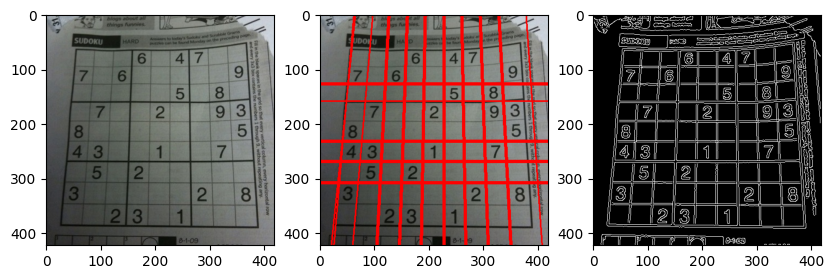

In [35]:
blured = cv.GaussianBlur(sodoku_img, (5,5), 0)
edges = cv.Canny(to_gray(blured), 10, 50)
draw_img = sodoku_img.copy()

lines = cv.HoughLines(edges, 1, np.pi/180, 190)
for line in lines:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv.line(draw_img,(x1,y1),(x2,y2),(0,0,255),2)

plt.figure(figsize=[10,10])
plt.subplot(131);plt.imshow(sodoku_img[..., ::-1])
plt.subplot(132);plt.imshow(draw_img[..., ::-1])
plt.subplot(133);plt.imshow(edges, cmap='gray')

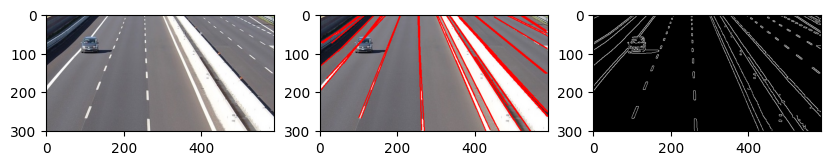

In [32]:
blured = cv.GaussianBlur(highway_lanes_img, (5,5), 0)
edges = cv.Canny(to_gray(blured), 50, 150)
draw_img = highway_lanes_img.copy()

lines = cv.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=20, maxLineGap=50)
for line in lines:
    x1,y1,x2,y2 = line[0]
    cv.line(draw_img,(x1,y1),(x2,y2),(0,0,255),2)

plt.figure(figsize=[10,10])
plt.subplot(131);plt.imshow(highway_lanes_img[..., ::-1])
plt.subplot(132);plt.imshow(draw_img[..., ::-1])
plt.subplot(133);plt.imshow(edges, cmap='gray')